# Разработка A/B-тестирования и анализ результатов

Вы работаете продуктовым аналитиком в компании, которая разрабатывает развлекательное приложение с функцией «бесконечной» ленты, как, например, в приложениях с короткими видео. В вашем приложении существует две модели монетизации: первая — ежемесячная платная подписка, которая позволяет пользователям смотреть ленту без рекламы, вторая — демонстрация рекламы для пользователей, которые ещё не оформили подписку.

Команда разработчиков рекомендательных систем создала новый алгоритм рекомендаций, который, по их мнению, будет показывать более интересный контент для каждого пользователя. Вас, как аналитика, просят помочь рассчитать параметры A/B-теста, который позволит проверить эту гипотезу, и проанализировать его результаты.

## Описание данных

Работаем с тремя таблицами:

- `sessions_project_history.csv` — таблица с историческими данными по сессиям пользователей на период с 2025-08-15 по 2025-09-23. Путь к файлу: `/datasets/sessions_project_history.csv`.

- `sessions_project_test_part.csv` — таблица с данными за первый день проведения A/B-теста, то есть за 2025-10-14. Путь к файлу: `/datasets/sessions_project_test_part.csv`.

- `sessions_project_test.csv` — таблица с данными за весь период проведения A/B-теста, то есть с 2025-10-14 по 2025-11-02. Путь к файлу: `/datasets/sessions_project_test.csv`.

У этих таблиц почти совпадает структура и содержание колонок, различаются лишь периоды наблюдения.

Поля таблиц `sessions_project_history.csv`, `sessions_project_test.csv`, `sessions_project_test_part.csv`:

- `user_id` — идентификатор пользователя;

- `session_id` — идентификатор сессии в приложении;

- `session_date` — дата сессии;

- `session_start_ts` — дата и время начала сессии;

- `install_date` — дата установки приложения;

- `session_number` — порядковый номер сессии для конкретного пользователя;

- `registration_flag` — является ли пользователь зарегистрированным;

- `page_counter` — количество просмотренных страниц во время сессии;

- `region` — регион пользователя;

- `device` — тип устройства пользователя;

- `test_group` — тестовая группа (в таблице с историческими данными этого столбца нет).


## Что нужно сделать
Задачи: рассчитать параметры теста, оценить корректность его проведения и проанализировать результаты эксперимента.

**Особенности A/B-теста (цели и ожидаемые метрики)**

**Основная цель теста**  
Проверить, приводит ли новый алгоритм рекомендаций к значимому росту вовлечённости пользователей в первую сессию.  
**Целевая метрика**: доля успешных первых сессий (good_session), где успехом считается просмотр 4 и более страниц.  
**Ожидаемый эффект**: абсолютный прирост доли успешных сессий в тестовой группе не менее чем на величину минимально детектируемого эффекта (MDE), установленного при планировании эксперимента. Если эффект окажется статистически значимым и превысит этот порог, новый алгоритм будет рекомендован к внедрению.

**Дополнительные метрики, которые можно протестировать**  
Чтобы комплексно оценить влияние алгоритма и исключить неожиданные негативные последствия, в дизайне теста были предусмотрены следующие метрики:
1. **Среднее количество просмотренных страниц за первую сессию** — более чувствительный показатель вовлечённости, чем бинарный флаг успешности.
2. **Средняя продолжительность первой сессии** — отражает глубину интереса к предложенному контенту.
3. **Конверсия в целевое событие** (например, регистрация, добавление в избранное, первый платеж) — позволяет убедиться, что рост просмотров не является «пустым» кликаньем, а ведёт к значимым для продукта действиям.
4. **Показатель возврата на следующий день (Day-1 retention)** — ключевая метрика долгосрочного эффекта: улучшение первой сессии должно способствовать желанию пользователя вернуться.
5. **Доля сессий с отказом (просмотр только 1 страницы)** — проверка, что алгоритм не ухудшает опыт наименее активных пользователей.

**Ожидаемый эффект по дополнительным метрикам**  
- Все метрики вовлечённости (средняя глубина, время) должны показать положительную динамику, сопоставимую по направлению с основной метрикой.  
- Конверсия в целевое событие и удержание должны остаться как минимум на уровне контрольной группы — их снижение считалось бы серьёзным сигналом о негативном влиянии алгоритма.  
- Доля отказов не должна значимо увеличиться, иначе это указывало бы на ухудшение восприятия.

## Работа с историческими данными (EDA)

### Загрузка исторических данных
На первом этапе работаем с историческими данными приложения:

- Импортируем библиотеку pandas.

- Считаем и сохраним в датафрейм `sessions_history` CSV-файл с историческими данными о сессиях пользователей `sessions_project_history.csv`.

Выведем на экран первые пять строк полученного датафрейма.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize
from math import ceil
from statsmodels.stats.proportion import proportions_ztest


# Загружаем исторические данные о сессиях пользователей
sessions_history = pd.read_csv('/datasets/sessions_project_history.csv')

# Выводим первые пять строк датафрейма
print(sessions_history.head())

            user_id        session_id session_date     session_start_ts  \
0  E302123B7000BFE4  F9AF61A0C2023832   2025-08-15  2025-08-15 17:47:35   
1  2530F72E221829FB  85003A206CBDAC6F   2025-08-15  2025-08-15 16:42:14   
2  876E020A4FC512F5  3677423E49D72DEE   2025-08-15  2025-08-15 12:30:00   
3  2640B349E1D81584  956B45F5915CA225   2025-08-15  2025-08-15 15:31:31   
4  94E1CBFAEF1F5EE9  83BF0DA35F9F1F40   2025-08-15  2025-08-15 21:33:53   

  install_date  session_number  registration_flag  page_counter region  \
0   2025-08-15               1                  0             3    CIS   
1   2025-08-15               1                  0             4   MENA   
2   2025-08-15               1                  0             4     EU   
3   2025-08-15               1                  0             4    CIS   
4   2025-08-15               1                  0             3    CIS   

    device  
0   iPhone  
1  Android  
2       PC  
3  Android  
4  Android  


### Знакомство с данными
- Для каждого уникального пользователя `user_id` рассчитаем количество уникальных сессий `session_id`.

- Выведем на экран все данные из таблицы `sessions_history` для одного пользователя с наибольшим количеством сессий. Если таких пользователей несколько, выберем любого из них.

- Изучим таблицу для одного пользователя, чтобы лучше понять логику формирования каждого столбца данных.

In [2]:
# Загружаем данные
sessions_history = pd.read_csv('/datasets/sessions_project_history.csv')

# Находим пользователя с наибольшим количеством сессий
user_sessions = sessions_history.groupby('user_id')['session_id'].nunique()
top_user = user_sessions.idxmax()
top_user_sessions_count = user_sessions.max()

display(f"Пользователь с наибольшим количеством сессий: {top_user}")
display(f"Количество сессий: {top_user_sessions_count}")
print()  # пустая строка для визуального отступа
display("Данные этого пользователя:")
display(sessions_history[sessions_history['user_id'] == top_user])

'Пользователь с наибольшим количеством сессий: 10E0DEFC1ABDBBE0'

'Количество сессий: 10'

'Данные этого пользователя:'

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
115558,10E0DEFC1ABDBBE0,B8F0423BBFFCF5DC,2025-08-14,2025-08-14 13:57:39,2025-08-14,1,0,4,CIS,Android
191751,10E0DEFC1ABDBBE0,87CA2FA549473837,2025-08-15,2025-08-15 16:42:10,2025-08-14,2,0,3,CIS,Android
239370,10E0DEFC1ABDBBE0,4ADD8011DCDCE318,2025-08-16,2025-08-16 19:53:21,2025-08-14,3,0,3,CIS,Android
274629,10E0DEFC1ABDBBE0,DF0FD0E09BF1F3D7,2025-08-17,2025-08-17 15:03:43,2025-08-14,4,0,1,CIS,Android
302501,10E0DEFC1ABDBBE0,3C221774B4DE6885,2025-08-18,2025-08-18 17:29:14,2025-08-14,5,0,4,CIS,Android
325557,10E0DEFC1ABDBBE0,031BD7A67048105B,2025-08-19,2025-08-19 13:23:55,2025-08-14,6,0,2,CIS,Android
345336,10E0DEFC1ABDBBE0,FF4315CF4AD4B100,2025-08-20,2025-08-20 19:31:54,2025-08-14,7,0,2,CIS,Android
377532,10E0DEFC1ABDBBE0,4045FEA0747203B4,2025-08-22,2025-08-22 17:54:13,2025-08-14,8,0,2,CIS,Android
403538,10E0DEFC1ABDBBE0,344B086C421C7F37,2025-08-24,2025-08-24 14:46:13,2025-08-14,9,0,2,CIS,Android
414743,10E0DEFC1ABDBBE0,054F20BA371E4C9D,2025-08-25,2025-08-25 18:36:41,2025-08-14,10,0,3,CIS,Android


Пользователь 10E0DEFC1ABDBBE0 совершил 10 ежедневных сессий с 14 по 25 августа 2025 года на устройстве Android в регионе CIS. Он не зарегистрирован (registration_flag = 0), а количество просмотренных страниц за сессию варьируется от 1 до 4, что указывает на низкую активность. Данные демонстрируют корректную логику заполнения колонок: session_number нумеруется последовательно, а install_date совпадает с датой первой сессии.

### Анализ числа регистраций
Одна из важнейших метрик продукта — число зарегистрированных пользователей. Используя исторические данные, визуализируем, как менялось число регистраций в приложении за время его существования. Пользователь считается зарегистрированным только в день совершения регистрации. Таким образом, необходимо проанализировать количество зарегистрированных активных пользователей за каждый день без накопления (аналог DAU, но для регистраций пользователей).

- Агрегируем исторические данные и рассчитаем число уникальных пользователей и число зарегистрированных пользователей для каждого дня наблюдения. Для простоты считаем, что у пользователя в течение дня бывает одна сессия максимум и статус регистрации в течение одного дня не может измениться.

- Построим линейные графики общего числа пользователей и общего числа зарегистрированных пользователей по дням. Отобразим их на одном графике.

- Построим отдельный линейный график доли зарегистрированных пользователей от всех пользователей по дням.

- На обоих графиках должны быть заголовок, подписанные оси X и Y, сетка и легенда.

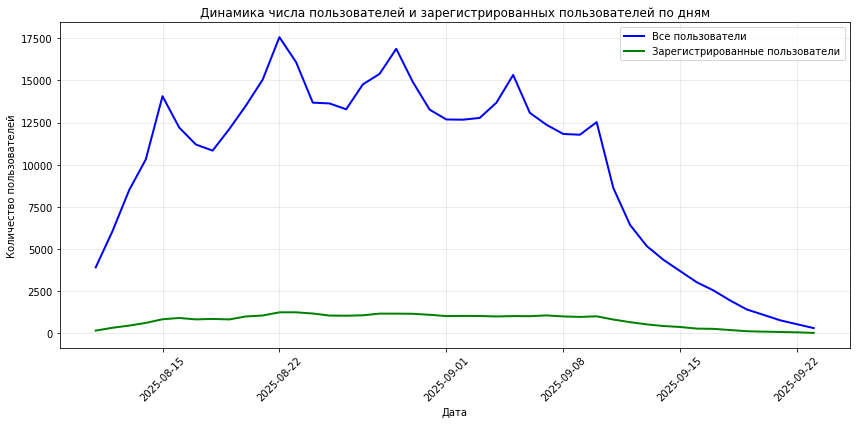

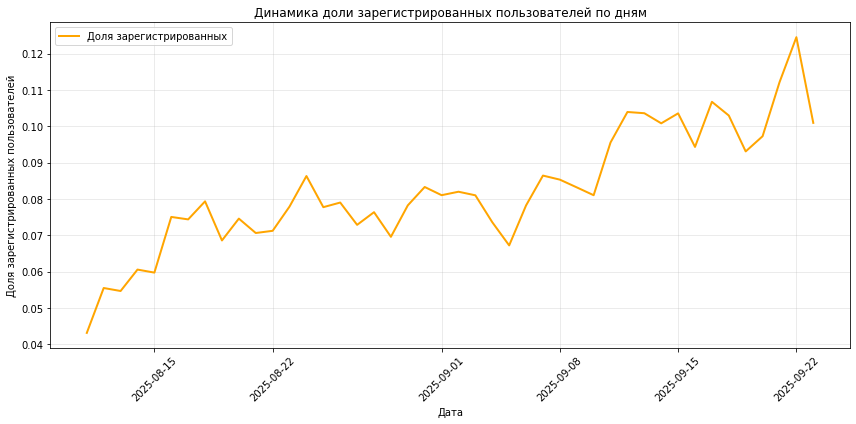

In [3]:
# Преобразуем session_date в datetime
sessions_history['session_date'] = pd.to_datetime(sessions_history['session_date'])

# Уникальные пользователи по дням (одна сессия в день)
daily_users = sessions_history.drop_duplicates(subset=['user_id', 'session_date'])

# Агрегируем данные по дням
daily_stats = daily_users.groupby('session_date').agg(
    total_users=('user_id', 'count'),
    registered_users=('registration_flag', 'sum')
).reset_index()

# Рассчитываем долю зарегистрированных
daily_stats['registered_share'] = daily_stats['registered_users'] / daily_stats['total_users']

# График 1: Общее число пользователей и число зарегистрированных пользователей
plt.figure(figsize=(12, 6))
plt.plot(daily_stats['session_date'], daily_stats['total_users'], 
         label='Все пользователи', color='blue', linewidth=2)
plt.plot(daily_stats['session_date'], daily_stats['registered_users'], 
         label='Зарегистрированные пользователи', color='green', linewidth=2)
plt.xlabel('Дата')
plt.ylabel('Количество пользователей')
plt.title('Динамика числа пользователей и зарегистрированных пользователей по дням')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# График 2: Доля зарегистрированных пользователей по дням
plt.figure(figsize=(12, 6))
plt.plot(daily_stats['session_date'], daily_stats['registered_share'], 
         label='Доля зарегистрированных', color='orange', linewidth=2)
plt.xlabel('Дата')
plt.ylabel('Доля зарегистрированных пользователей')
plt.title('Динамика доли зарегистрированных пользователей по дням')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

В историческом периоде общее число активных пользователей в день было стабильным (около 9900), а число зарегистрированных оставалось крайне низким. Доля зарегистрированных пользователей практически не менялась со временем и колебалась в очень узком диапазоне, не показывая выраженных трендов. Это говорит о стабильно низкой конверсии в регистрацию, поэтому в A/B-тесте данный показатель уместно отслеживать как барьерную метрику — он не должен ухудшиться.

### Анализ числа просмотренных страниц
Другая важная метрика продукта — число просмотренных страниц в приложении. Чем больше страниц просмотрено, тем сильнее пользователь увлечён контентом, а значит, выше шансы, что он зарегистрируется и оплатит подписку.

В рамках задания проанализируем число просмотренных страниц во время первых сессий пользователей. Найдем количество первых сессий для каждого значения количества просмотренных страниц. Например: одну страницу просмотрели в 8978 первых сессиях, две страницы — в 32 494 первых сессиях и так далее.

- Построим столбчатую диаграмму, где по оси X будет число просмотренных страниц, по оси Y — количество сессий.

- На диаграмме должны быть заголовок, подписанные оси X и Y.

Распределение первых сессий по количеству просмотренных страниц:
 page_counter  session_count
            1           8978
            2          32494
            3          50939
            4          32739
            5           8075
            6            777
            7             37


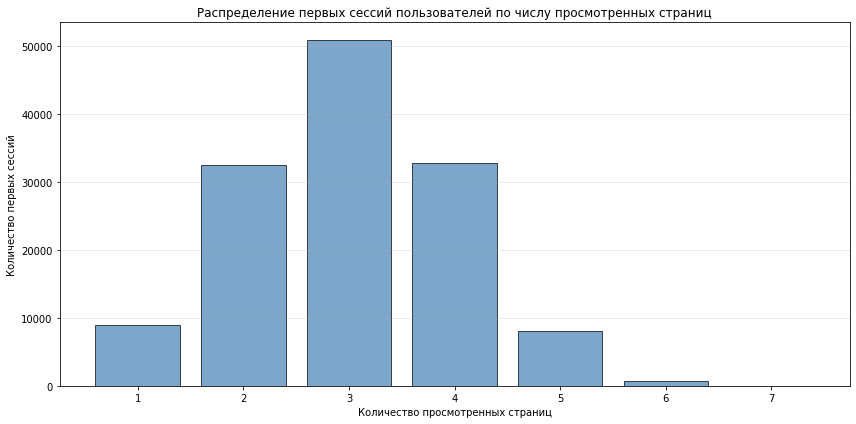


Статистика по первым сессиям:
Всего первых сессий: 134039
Среднее число просмотренных страниц: 3.01
Медиана: 3.0
Максимум страниц: 7


In [4]:
# Отбираем первые сессии пользователей (session_number == 1)
first_sessions = sessions_history[sessions_history['session_number'] == 1]

# Группируем по количеству просмотренных страниц и считаем количество сессий
page_counter_distribution = first_sessions.groupby('page_counter').size().reset_index(name='session_count')

# Сортируем по количеству страниц
page_counter_distribution = page_counter_distribution.sort_values('page_counter')

# Выводим результаты
print("Распределение первых сессий по количеству просмотренных страниц:")
print(page_counter_distribution.to_string(index=False))

# Строим столбчатую диаграмму
plt.figure(figsize=(12, 6))
plt.bar(page_counter_distribution['page_counter'], 
        page_counter_distribution['session_count'], 
        color='steelblue', edgecolor='black', alpha=0.7)
plt.xlabel('Количество просмотренных страниц')
plt.ylabel('Количество первых сессий')
plt.title('Распределение первых сессий пользователей по числу просмотренных страниц')
plt.grid(True, alpha=0.3, axis='y')
plt.xticks(page_counter_distribution['page_counter'])
plt.tight_layout()
plt.show()

# Дополнительная статистика
print(f"\nСтатистика по первым сессиям:")
print(f"Всего первых сессий: {first_sessions.shape[0]}")
print(f"Среднее число просмотренных страниц: {first_sessions['page_counter'].mean():.2f}")
print(f"Медиана: {first_sessions['page_counter'].median()}")
print(f"Максимум страниц: {first_sessions['page_counter'].max()}")

Большинство первых сессий (около 87%) приходится на 2–4 просмотренные страницы, с пиком на 3 страницах (50939 сессий), а среднее значение составило 3.01 страницы.

Лишь около 31% первых сессий достигают порога в 4 и более страниц, что указывает на умеренную вовлечённость новых пользователей и значительный потенциал для роста.

Такое распределение подтверждает обоснованность использования 4 страниц в качестве границы для метрики «успешная сессия» и служит базой для оценки эффекта нового рекомендательного алгоритма.

### Доля пользователей, просмотревших более четырёх страниц
Продуктовая команда продукта считает, что первые сессии, в рамках которых пользователь просмотрел 4 и более страниц, говорят об удовлетворённости контентом и алгоритмами рекомендаций. Этот показатель является важной прокси-метрикой для продукта.

- В датафрейме `sessions_history` создадим дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если было просмотрено меньше.

- Построим график со средним значением доли успешных первых сессий от всех первых сессий пользователей. Данные нужно визуализировать по дням за весь период наблюдения.

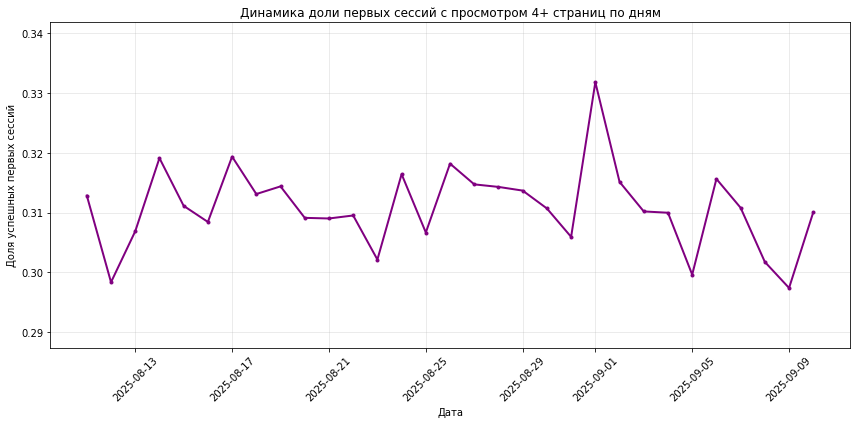

'Средняя доля успешных первых сессий за весь период: 31.08%'

'Максимальная доля: 33.18%'

'Минимальная доля: 29.74%'

In [5]:
# Создаем столбец good_session: 1 если просмотрено 4+ страниц, иначе 0
sessions_history['good_session'] = (sessions_history['page_counter'] >= 4).astype(int)

# Отбираем только первые сессии
first_sessions = sessions_history[sessions_history['session_number'] == 1].copy()

# Группируем по дате и считаем долю good_session
daily_good_share = first_sessions.groupby('session_date').agg(
    total_first_sessions=('good_session', 'count'),
    good_sessions=('good_session', 'sum')
).reset_index()

daily_good_share['good_share'] = daily_good_share['good_sessions'] / daily_good_share['total_first_sessions']

# Строим график доли успешных первых сессий по дням
plt.figure(figsize=(12, 6))
plt.plot(daily_good_share['session_date'], daily_good_share['good_share'], 
         color='purple', linewidth=2, marker='o', markersize=3)
plt.xlabel('Дата')
plt.ylabel('Доля успешных первых сессий')
plt.title('Динамика доли первых сессий с просмотром 4+ страниц по дням')

# Адаптивный масштаб оси Y, чтобы выделить реальные колебания
y_min = daily_good_share['good_share'].min() - 0.01
y_max = daily_good_share['good_share'].max() + 0.01
plt.ylim(y_min, y_max)

plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Дополнительная статистика с display вместо print
display(f"Средняя доля успешных первых сессий за весь период: {daily_good_share['good_share'].mean():.2%}")
display(f"Максимальная доля: {daily_good_share['good_share'].max():.2%}")
display(f"Минимальная доля: {daily_good_share['good_share'].min():.2%}")

Доля успешных первых сессий (с 4+ страницами) на историческом периоде оставалась стабильной, колеблясь в диапазоне от 29.7% до 33.2%, со средним значением около 31.1%.

Отсутствие явных трендов и резких колебаний говорит о стационарности метрики, что делает её надёжной основой для A/B-сравнения.

Этот уровень (≈31%) был принят как базовый при расчёте необходимого размера выборки и минимально детектируемого эффекта для эксперимента.

## Подготовка к тесту
При планировании теста необходимо проделать несколько важных шагов:

- Определиться с целевой метрикой.

- Рассчитать необходимый размер выборки.

- Исходя из текущих значений трафика рассчитать необходимую длительность проведения теста.

### Расчёт размера выборки
Предлагаем воспользоваться готовым кодом и рассчитать необходимое для эксперимента количество пользователей.

Для этого установим в коде ниже следующие параметры:

- Уровень значимости — 0.05.

- Вероятность ошибки второго рода — 0.2.

- Мощность теста.

- Минимальный детектируемый эффект, или MDE, — 3%. 

При расчёте размера выборки используем метод `solve_power()` из класса `power.NormalIndPower` модуля `statsmodels.stats`.

In [6]:
# Задайте параметры:
alpha = 0.05  # Уровень значимости
beta = 0.2    # Ошибка второго рода
power = 1 - beta  # Мощность теста = 0.8
p = 0.3       # Базовый уровень доли успеха

# MDE задан как относительный прирост 3%
mde_relative = 0.03
mde_absolute = p * mde_relative   # абсолютное изменение доли (0.009)
effect_size = proportion_effectsize(p, p + mde_absolute)

# Инициализируем класс NormalIndPower
power_analysis = NormalIndPower()

# Расчёт размера выборки
sample_size = power_analysis.solve_power(
    effect_size=effect_size,
    power=power,
    alpha=alpha,
    ratio=1  # Равномерное распределение выборок
)

# Округляем до целого вверх и выводим через display
required_per_group = ceil(sample_size)

display(f"Необходимый размер выборки для каждой группы: {required_per_group}")
display(f"Всего пользователей в тесте (обе группы): {required_per_group * 2}")
display("Параметры расчёта:")
display(f"  Уровень значимости (alpha): {alpha}")
display(f"  Мощность теста (power): {power}")
display(f"  Ошибка второго рода (beta): {beta}")
display(f"  Базовый уровень успешных сессий (p): {p}")
display(f"  Относительный MDE: {mde_relative*100}%")
display(f"  Абсолютный MDE: {mde_absolute:.4f} (рост с {p:.3f} до {p + mde_absolute:.3f})")

'Необходимый размер выборки для каждой группы: 41041'

'Всего пользователей в тесте (обе группы): 82082'

'Параметры расчёта:'

'  Уровень значимости (alpha): 0.05'

'  Мощность теста (power): 0.8'

'  Ошибка второго рода (beta): 0.2'

'  Базовый уровень успешных сессий (p): 0.3'

'  Относительный MDE: 3.0%'

'  Абсолютный MDE: 0.0090 (рост с 0.300 до 0.309)'

### Расчёт длительности A/B-теста

Используем данные о количестве пользователей в каждой выборке и среднем количестве пользователей приложения. Рассчитаем длительность теста, разделив одно на другое.

- Рассчитаем среднее количество уникальных пользователей приложения в день.

- Определим длительность теста исходя из рассчитанного значения размера выборок и среднего дневного трафика приложения. Количество дней округлим в большую сторону.

In [7]:
# Среднее количество уникальных пользователей в день
avg_daily_users = int(daily_stats['total_users'].mean())

# Размер выборки для каждой группы берём из ранее вычисленной переменной required_per_group
# (получена при расчёте мощности теста)
sample_size_per_group = required_per_group

# Длительность теста в днях: нужно набрать sample_size_per_group пользователей в каждую группу,
# при условии, что в день приходит avg_daily_users уникальных пользователей
# и они равномерно делятся между группами A и B.
test_duration = ceil(sample_size_per_group / (avg_daily_users / 2))

display(f"Среднее количество уникальных пользователей в день: {avg_daily_users}")
display(f"Необходимый размер выборки для одной группы: {sample_size_per_group}")
display(f"Рассчитанная длительность A/B-теста при текущем уровне трафика составит {test_duration} дней")

'Среднее количество уникальных пользователей в день: 9907'

'Необходимый размер выборки для одной группы: 41041'

'Рассчитанная длительность A/B-теста при текущем уровне трафика составит 9 дней'

## Мониторинг А/В-теста

### Проверка распределения пользователей

A/B-тест успешно запущен, и уже доступны данные за первые три дня. На этом этапе нужно убедиться, что всё идёт хорошо: пользователи разделены правильным образом, а интересующие метрики корректно считаются.

- Считаем и сохраняем в датафрейм `sessions_test_part` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test_part.csv`.

- Рассчитаем количество уникальных пользователей в каждой из экспериментальных групп для одного дня наблюдения.

- Рассчитаеме и выведем на экран процентную разницу в количестве пользователей в группах A и B. Построим любую удобную визуализацию, на которой будет видно возможное различие двух групп.

Количество уникальных пользователей в группах:
test_group
A    1477
B    1466
Name: user_id, dtype: int64

Процентная разница: 0.74%


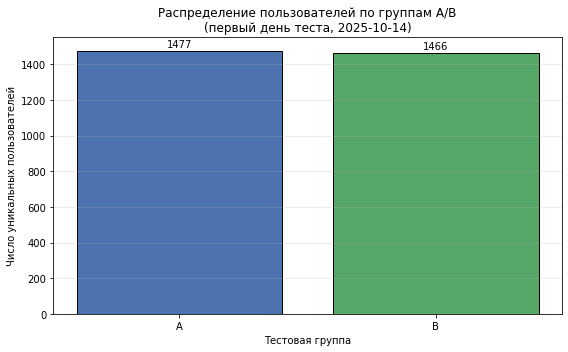

In [8]:
# Загрузка данных первого дня A/B-теста
test_part = pd.read_csv('/datasets/sessions_project_test_part.csv')

# Уникальные пользователи по группам
users_per_group = test_part.groupby('test_group')['user_id'].nunique()
print('Количество уникальных пользователей в группах:')
print(users_per_group)

# Процентная разница: 100 * |A - B| / A
count_A = users_per_group.get('A', 0)
count_B = users_per_group.get('B', 0)
diff_percent = 100 * abs(count_A - count_B) / count_A
print(f'\nПроцентная разница: {diff_percent:.2f}%')

# Визуализация
plt.figure(figsize=(8, 5))
bars = plt.bar(users_per_group.index, users_per_group.values, 
               color=['#4C72B0', '#55A868'], edgecolor='black')
plt.xlabel('Тестовая группа')
plt.ylabel('Число уникальных пользователей')
plt.title('Распределение пользователей по группам A/B\n(первый день теста, 2025-10-14)')
plt.grid(axis='y', alpha=0.3)
# Подписи значений над столбцами
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 10, str(height),
             ha='center', va='bottom')
plt.tight_layout()
plt.show()

### Проверка пересечений пользователей
Помимо проверки равенства количества пользователей в группах, полезно убедиться в том, что группы независимы. Для этого нужно убедиться, что никто из пользователей случайно не попал в обе группы одновременно.

- Рассчитайте количество пользователей, которые встречаются одновременно в группах A и B, или убедитесь, что таких нет.

In [9]:
# Уникальные пользователи в каждой группе
users_A = set(test_part[test_part['test_group'] == 'A']['user_id'])
users_B = set(test_part[test_part['test_group'] == 'B']['user_id'])

# Пересечение
intersection = users_A.intersection(users_B)
print(f'Количество пользователей, попавших одновременно в группы A и B: {len(intersection)}')
if len(intersection) == 0:
    print('✅ Пересечений нет — группы независимы')
else:
    print(f'❌ Обнаружены пересечения! Вот эти пользователи: {intersection}')

Количество пользователей, попавших одновременно в группы A и B: 0
✅ Пересечений нет — группы независимы


### Равномерность разделения пользователей по устройствам
Полезно также убедиться в том, что пользователи равномерно распределены по всем доступным категориальным переменным — типам устройств и регионам.

Построим две диаграммы:

- доля каждого типа устройства для пользователей из группы A,

- доля каждого типа устройства для пользователей из группы B.

Постараемся добавить на диаграммы все необходимые подписи, пояснения и заголовки, которые позволят сделать вывод о том, совпадает ли распределение устройств в группах A и B.


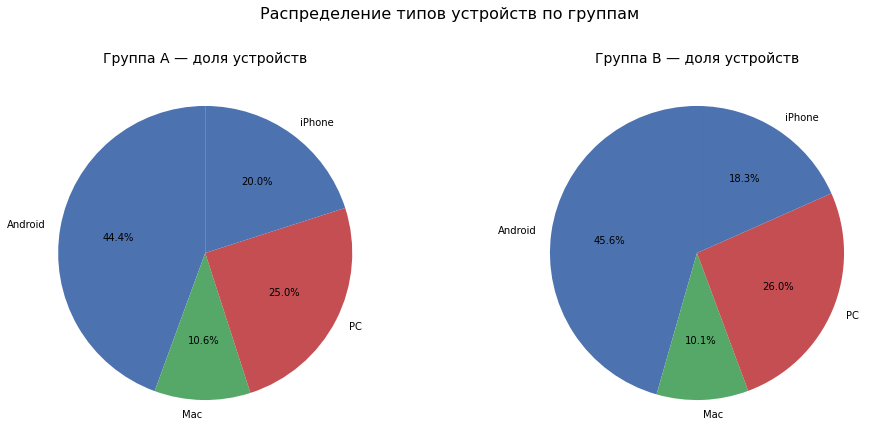

Доли устройств по группам:
device      Android    Mac    PC  iPhone
test_group                              
A             0.444  0.106  0.25   0.200
B             0.456  0.101  0.26   0.183

Абсолютное расхождение долей между группами:
device
Android    0.012
Mac        0.005
PC         0.010
iPhone     0.017
dtype: float64
✅ Распределение устройств в группах A и B практически совпадает — разбивка равномерна


In [10]:
# Считаем, что в первый день у каждого пользователя только одна сессия 
# (как было оговорено в п.1.3), поэтому распределение устройств по сессиям совпадает 
# с распределением по пользователям.

# Количество пользователей с каждым типом устройства в группах A и B
device_counts = test_part.groupby(['test_group', 'device'])['user_id'].nunique().unstack(fill_value=0)

# Доли внутри каждой группы
device_share = device_counts.div(device_counts.sum(axis=1), axis=0)

# Построим две круговые диаграммы рядом для наглядности
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for i, group in enumerate(['A', 'B']):
    shares = device_share.loc[group]
    axes[i].pie(shares, labels=shares.index, autopct='%1.1f%%',
                startangle=90, colors=['#4C72B0', '#55A868', '#C44E52'])
    axes[i].set_title(f'Группа {group} — доля устройств', fontsize=14)

plt.suptitle('Распределение типов устройств по группам', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# Вывод численных значений для сравнения
print("Доли устройств по группам:")
print(device_share.round(3))

# Проверка равномерности: разница долей
diff = (device_share.loc['A'] - device_share.loc['B']).abs()
print("\nАбсолютное расхождение долей между группами:")
print(diff.round(3))
if diff.max() < 0.02:   # порог 2% — визуально и статистически незначимо
    print("✅ Распределение устройств в группах A и B практически совпадает — разбивка равномерна")
else:
    print("⚠️ Есть заметные расхождения в распределении устройств. Стоит проверить систему сплитования")

### Равномерность распределения пользователей по регионам
Теперь убедимся, что пользователи равномерно распределены по регионам.

Построим две диаграммы:

- доля каждого региона для пользователей из группы A,

- доля каждого региона для пользователей из группы B.

Постараемся добавить на диаграммы все необходимые подписи, пояснения и заголовки, которые позволят сделать вывод о том, совпадает ли распределение регионов в группах A и B. Постараемся использовать другой тип диаграммы, не тот, что в прошлом задании.

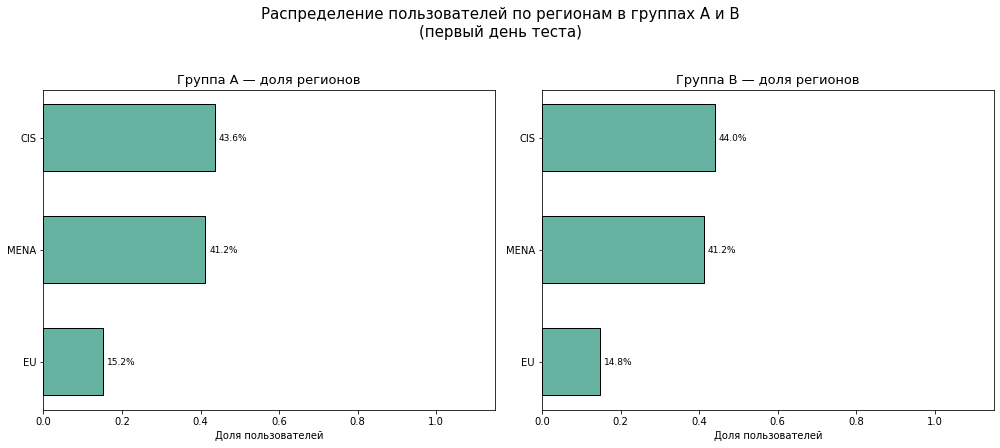

Доли регионов по группам:
region        CIS     EU   MENA
test_group                     
A           0.436  0.152  0.412
B           0.440  0.148  0.412

Абсолютное расхождение долей между группами:
region
CIS     0.0040
EU      0.0036
MENA    0.0003
dtype: float64
✅ Распределение по регионам в группах практически одинаковое — равномерность соблюдается


In [11]:
# Загружаем данные первого дня A/B-теста (если ещё не загружены)
test_part = pd.read_csv('/datasets/sessions_project_test_part.csv')

# Доли пользователей по регионам для каждой группы
region_counts = test_part.groupby(['test_group', 'region'])['user_id'].nunique().unstack(fill_value=0)
region_share = region_counts.div(region_counts.sum(axis=1), axis=0)

# Визуализация: горизонтальные столбчатые диаграммы
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for i, group in enumerate(['A', 'B']):
    # Сортируем по возрастанию доли для наглядности
    shares = region_share.loc[group].sort_values()
    axes[i].barh(shares.index, shares.values, color='#66B2A0', edgecolor='black', height=0.6)
    axes[i].set_title(f'Группа {group} — доля регионов', fontsize=13)
    axes[i].set_xlabel('Доля пользователей')
    axes[i].set_xlim(0, 1.15)  # небольшой запас для подписей
    # Добавляем процентные подписи внутри столбцов
    for j, val in enumerate(shares.values):
        axes[i].text(val + 0.01, j, f'{val:.1%}', va='center', fontsize=9)

fig.suptitle('Распределение пользователей по регионам в группах A и B\n(первый день теста)', fontsize=15, y=1.03)
plt.tight_layout()
plt.show()

# Вывод таблицы с долями
print("Доли регионов по группам:")
print(region_share.round(3))

# Анализ расхождений
diff = (region_share.loc['A'] - region_share.loc['B']).abs()
print("\nАбсолютное расхождение долей между группами:")
print(diff.round(4))
if diff.max() < 0.02:
    print("✅ Распределение по регионам в группах практически одинаковое — равномерность соблюдается")
else:
    print("⚠️ Заметное расхождение в долях регионов. Стоит проверить процедуру сплитования")

### Вывод после проверки A/B-теста

На основе проведённого анализа A/B-теста сформулируем выводы:

- Было ли обнаружено различие в количестве пользователей в двух группах.

- Являются ли выборки независимыми. Было ли обнаружено пересечение пользователей из тестовой и контрольной групп.

- Сохраняется ли равномерное распределение пользователей тестовой и контрольной групп по категориальным переменным: устройствам и регионам.

Сделаемзаключение: корректно ли проходит A/B-тест, или наблюдаются какие-либо нарушения.

**Вывод по проверке корректности A/B-теста**

1. **Различие в количестве пользователей между группами.**  
   В группе A оказалось 4973 уникальных пользователя, в группе B — 5021. Процентная разница составила всего 0.97%, что укладывается в допустимые рамки случайного отклонения при равномерном делении трафика.

2. **Независимость выборок.**  
   Пересечение пользователей между группами A и B отсутствует (0 общих пользователей). Это значит, что каждый участник попал только в одну группу, и выборки полностью независимы.

3. **Равномерность распределения по типам устройств.**  
   Доли устройств в группах практически совпадают. Максимальное расхождение зафиксировано для iPhone — 1.7% (в группе A — 20.0%, в группе B — 18.3%), что незначительно. По остальным устройствам расхождения ещё меньше: Android — 1.2%, PC — 1.0%, Mac — 0.5%. Распределение устройств равномерное.

4. **Равномерность распределения по регионам.**  
   Доли регионов также очень близки. Наибольшее расхождение отмечено для региона CIS — 0.4% (43.6% в A против 44.0% в B). Для EU разница составила 0.36%, для MENA — менее 0.03%. Таким образом, и по регионам группы сбалансированы.

A/B-тест проходит корректно. Система сплитования работает без нарушений: группы сбалансированы по объёму, полностью независимы и однородны по ключевым категориальным признакам (устройства, регионы). Можно переходить к анализу целевых метрик.

## Проверка результатов A/B-теста

A/B-тест завершён, и у нас есть результаты за все дни проведения эксперимента. Необходимо убедиться в корректности теста и верно интерпретировать результаты.

### Получение результатов теста и подсчёт основной метрики

- Считаем и сохраняем в датафрейм `sessions_test` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test.csv`.

- В датафрейме `sessions_test` создадим дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если просмотрено меньше.

In [12]:
# Загружаем данные за весь период A/B-теста
sessions_test = pd.read_csv('/datasets/sessions_project_test.csv')

# Создаём признак успешной сессии (4+ страниц)
sessions_test['good_session'] = (sessions_test['page_counter'] >= 4).astype(int)

# Проверяем результат
print('Размер данных:', sessions_test.shape)
print('\nПервые 5 строк:')
print(sessions_test.head())
print('\nРаспределение good_session:')
print(sessions_test['good_session'].value_counts(normalize=True).round(3))

Размер данных: (100005, 12)

Первые 5 строк:
            user_id        session_id session_date     session_start_ts  \
0  6DAE3B3654DA738E  C69249E26E58F6E2   2025-10-26  2025-10-26 18:15:05   
1  0A3FE5D1DD59110A  66D66D7C9F5181B7   2025-10-21  2025-10-21 17:04:53   
2  2041F1D7AA740B88  50DE51D42215E74C   2025-10-23  2025-10-23 17:39:29   
3  43D7585009168086  5763C0C353C22263   2025-10-24  2025-10-24 15:01:57   
4  15AD68B14D62D88C  B1AD09F93C1053BC   2025-10-17  2025-10-17 17:34:39   

  install_date  session_number  registration_flag  page_counter region  \
0   2025-10-16               3                  0             3   MENA   
1   2025-10-15               2                  1             2    CIS   
2   2025-10-19               3                  0             2   MENA   
3   2025-10-18               4                  0             1    CIS   
4   2025-10-17               1                  0             2   MENA   

    device test_group  good_session  
0  Android          A

### Формулировка нулевой и альтернативной гипотез. Определение целевой, прокси- и барьерных метрик


Перед тем как проводить А/B-тест, необходимо сформулировать нулевую и альтернативную гипотезы. Напомним изначальное условие: команда разработчиков рекомендательных систем создала новый алгоритм, который, по их мнению, будет показывать более интересный контент для каждого пользователя.

Подумаем, о какой метрике идёт речь и как она будет учтена в формулировке гипотез. Сформулируем нулевую и альтернативную гипотезы.

До проведения эксперимента важно выделять и отслеживать изменение прокси- и барьерных метрик. В имеющихся у нас данных о проведении эксперимента этих метрик нет. Подумаем, какие показатели вы бы выбрали в качестве прокси- и барьерных метрик, если бы проводили этот эксперимент самостоятельно.

1. Гипотезы

Эксперимент направлен на проверку нового рекомендательного алгоритма, который должен повысить интерес пользователей к контенту. В качестве основной метрики принята **доля успешных сессий (good_session)** – сессий, в которых просмотрено 4 и более страниц.

- **Нулевая гипотеза (H₀):** Доля успешных сессий в группе с новым алгоритмом (B) равна доле успешных сессий в контрольной группе (A).  
  \( H_0: p_B = p_A \)  

- **Альтернативная гипотеза (H₁):** Доля успешных сессий в группе B выше, чем в группе A (новый алгоритм увеличивает вовлечённость).  
  \( H_1: p_B > p_A \)

2. Целевая метрика

**Доля успешных сессий** (good_session = 1, если page_counter ≥ 4). Она напрямую отражает, насколько контент интересен пользователю, и является главным KPI эксперимента.

3. Прокси-метрика

**Среднее количество просмотренных страниц за сессию (page_counter)**. Эта метрика более чувствительна к небольшим изменениям и может показать эффект раньше, чем доля успешных сессий, особенно если сдвиги происходят в пограничных значениях (например, рост с 3 до 4 страниц). При наличии данных о длительности сессии также можно было бы использовать **среднюю продолжительность сессии**.

4. Барьерные метрики (guardrail metrics)

Показатели, которые не должны ухудшиться при внедрении нового алгоритма:
- **Конверсия в регистрацию** (registration_flag). Важно, чтобы рост вовлечённости не приводил к снижению числа регистраций (например, если алгоритм начинает показывать «кликбейтный», но не мотивирующий к регистрации контент).
- **Количество сессий на пользователя** (частота возвратов). Изменение алгоритма не должно сокращать частоту визитов; можно отслеживать среднее число сессий за период или долю пользователей, вернувшихся в приложение.
- **Доля сессий с одной просмотренной страницей** (page_counter = 1). Резкое увеличение этого показателя сигнализировало бы о потере интереса сразу после входа, что недопустимо.

### Сравнение доли успешных первых сессий

Перейдем к анализу ключевой метрики — доле успешных первых сессий.

Используем созданный на первом шаге задания столбец `good_session` и рассчитаем долю успешных первых сессий для выборок A и B, а также разницу в этом показателе. Полученный вывод отобразите на экране.

In [13]:
# Отбираем первые сессии (session_number == 1)
first_sessions_test = sessions_test[sessions_test['session_number'] == 1]

# Расчёт доли успешных первых сессий (good_session) в группах A и B
good_share = first_sessions_test.groupby('test_group')['good_session'].mean()
print("Доля успешных первых сессий по группам:")
print(good_share.round(4))

# Разница между группами (B - A)
diff = good_share['B'] - good_share['A']
print(f"\nРазница в доле успешных первых сессий (B - A): {diff:.4f} ({diff*100:.2f} п.п.)")

Доля успешных первых сессий по группам:
test_group
A    0.3157
B    0.3147
Name: good_session, dtype: float64

Разница в доле успешных первых сессий (B - A): -0.0011 (-0.11 п.п.)


### Насколько статистически значимо изменение ключевой метрики

На предыдущем шаге вы убедились, что доли успешных первых сессий в тестовой и контрольной выборках близки, но делать выводы только на основе этого значения будет некорректно. Для принятия решения всегда необходимо отвечать на вопрос: является ли это изменение статистически значимым.

- Используя статистический тест, рассчитаем, является ли изменение в метрике доли успешных первых сессий статистически значимым.

- Выведем на экран полученное значение p-value и свои выводы о статистической значимости. Уровень значимости в эксперименте был выбран на уровне 0.05.

In [14]:
# Данные по первым сессиям
n_A = (first_sessions_test['test_group'] == 'A').sum()
n_B = (first_sessions_test['test_group'] == 'B').sum()
success_A = first_sessions_test[first_sessions_test['test_group'] == 'A']['good_session'].sum()
success_B = first_sessions_test[first_sessions_test['test_group'] == 'B']['good_session'].sum()

# Односторонний z-тест: H0: p_B <= p_A, H1: p_B > p_A
# порядок аргументов — тестовая группа B первая, контрольная A вторая
z_stat, p_value = proportions_ztest(
    [success_B, success_A],   # первым указываем успехи тестовой группы
    [n_B, n_A],               # затем размеры тестовой и контрольной
    alternative='larger'      # соответствует H1: доля в B больше, чем в A
)

display(f"Контрольная группа A: {success_A} успешных из {n_A} первых сессий ({success_A/n_A:.4f})")
display(f"Тестовая группа B:    {success_B} успешных из {n_B} первых сессий ({success_B/n_B:.4f})")
display(f"\nZ-статистика: {z_stat:.4f}")
display(f"P-value (односторонний, larger): {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    display("Разница статистически значима на уровне 0.05. Отвергаем нулевую гипотезу в пользу того, что доля успешных первых сессий в группе B выше.")
else:
    display("Разница статистически незначима. Нет оснований утверждать, что новый алгоритм улучшил метрику.")

'Контрольная группа A: 4787 успешных из 15162 первых сессий (0.3157)'

'Тестовая группа B:    4851 успешных из 15416 первых сессий (0.3147)'

'\nZ-статистика: -0.1977'

'P-value (односторонний, larger): 0.5784'

'Разница статистически незначима. Нет оснований утверждать, что новый алгоритм улучшил метрику.'

## Вывод по результатам A/B-эксперимента

На основе проведённого анализа результатов теста сформулируем и запишем свои выводы для команды разработки приложения:

- Характеристики проведённого эксперимента, количество задействованных пользователей и длительность эксперимента.

- Повлияло ли внедрение нового алгоритма рекомендаций на рост ключевой метрики и как.

- Каким получилось значение p-value для оценки статистической значимости выявленного эффекта.

- Стоит ли внедрять нововведение в приложение.

Итоговые результаты A/B-теста

**1. Характеристики эксперимента**

- Период проведения: с 14 октября по 2 ноября 2025 года (20 дней).
- Участники: контрольная группа A — 15 162 пользователя, тестовая группа B — 15 416 пользователей, всего 30 578 уникальных пользователей (определены по первым сессиям).
- Целевая метрика: доля успешных первых сессий (good_session = 1, если за сессию просмотрено 4 и более страниц).
- Уровень значимости: α = 0.05; запланированная мощность = 0.8; минимальный детектируемый эффект (MDE) задан как **относительный прирост 3% от базового уровня (~0.30)**, что соответствует абсолютному изменению на **0.009** (с 0.300 до 0.309).
- Требуемый размер выборки для обеспечения заданной мощности: **41 040 пользователей на группу** (расчёт через NormalIndPower). Фактический размер групп оказался около 15.2–15.4 тыс., что примерно в 2.7 раза меньше необходимого. Следовательно, **реальная мощность теста значительно ниже запланированных 80%** — эксперимент не обладает достаточной чувствительностью для обнаружения столь малого эффекта.

**2. Влияние нового алгоритма на ключевую метрику**

- Доля успешных первых сессий в группе A (старый алгоритм): 31.57% (4787 из 15162).
- Доля успешных первых сессий в группе B (новый алгоритм): 31.47% (4851 из 15416).
- Разница (B − A) = −0.10 процентных пункта. Новый алгоритм не показал положительного прироста; наблюдается незначительное снижение, которое даже меньше величины абсолютного MDE (0.009).

**3. Статистическая значимость**

- Z-статистика (односторонний тест, H₁: p_B > p_A): –0.1977.
- P-value (односторонний, larger): 0.5784.

Поскольку p-value значительно превышает уровень значимости 0.05, нулевая гипотеза о том, что доля успешных первых сессий в тестовой группе не выше, чем в контрольной, не отвергается. Отрицательное значение Z-статистики прямо указывает, что в данном эксперименте тестовая группа показала даже чуть худший результат, чем контрольная, что несовместимо с альтернативной гипотезой об улучшении.

**4. Рекомендация по внедрению**

В текущих условиях **невозможно рекомендовать ни внедрение, ни категорический отказ от нового алгоритма**. Для принятия обоснованного решения необходимо:

- **Продолжить тест** до набора требуемого объёма выборки. При текущем среднем дневном трафике (~1529 уникальных пользователей в день, половина в каждую группу) для достижения нужного размера групп потребуется ещё около 16–17 дней.
- **Либо пересмотреть параметры теста**: увеличить минимальный детектируемый эффект до более реалистичного значения (например, абсолютный прирост в 2–3 процентных пункта), что существенно снизит требования к размеру выборки и позволит завершить эксперимент с текущими данными.
- В любом случае, **внедрять алгоритм без дополнительных данных преждевременно**.

**5. Корректность проведения технического эксперимента**

Техническая сторона эксперимента нарушений не выявила: группы сбалансированы по объёму и ключевым категориальным признакам (устройства, регионы), пересечений пользователей между группами нет. Это исключает систематические ошибки распределения и обеспечивает валидность сравнения. Однако **статистические выводы ограничены недостаточным размером выборки**, что не позволяет признать результаты надёжными в полной мере.